# LEVEL 2 Overrepresentation EDA

This notebook audits the synthetic smishing dataset with a narrow focus on `LEVEL 2 – Leet nặng + tên riêng`, which currently dominates `synthetic_label_1.csv`.

The goal is not only to count the imbalance, but to determine whether `LEVEL 2` is:

- a realistic representation of Vietnamese smishing style,
- an artifact of prompt templates or generation batches,
- a taxonomy problem where several distinct transformations were collapsed into one level,
- or a data-quality issue that should be corrected before the final merge.

Primary input: `../synthetic/synthetic_label_1.csv`.

Optional output from this notebook: `level2_review_samples.csv`, a compact manual-review sample.

## Analysis Plan

1. Load and validate the current synthetic smishing data.
2. Quantify the global and per-category `level` distribution.
3. Compare observed vs expected counts to identify which categories drive the `LEVEL 2` surplus.
4. Measure surface obfuscation: digit ratio, symbol ratio, uppercase ratio, dot/dash insertion, leet-like substitutions, and random suffix codes.
5. Compare `LEVEL 2` against all other levels to see whether the label reflects distinct text behavior.
6. Detect likely template reuse using normalized skeletons.
7. Pull qualitative review samples, including high-confidence and suspicious `LEVEL 2` rows.
8. Convert findings into dataset decisions: rebalance, relabel, regenerate, or revise taxonomy/prompts.

In [1]:
from pathlib import Path
import math
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 180)
pd.set_option('display.max_rows', 100)

DATA_PATH = Path('../synthetic/synthetic_label_1.csv')
REPORT_DIR = Path('.')
SAMPLE_OUT = REPORT_DIR / 'level2_review_samples.csv'

LEVEL2 = 'LEVEL 2 – Leet nặng + tên riêng'

df = pd.read_csv(DATA_PATH)
df['content'] = df['content'].fillna('').astype(str)

print(df.shape)
display(df.head())
display(df.dtypes)

(5000, 7)


,content,label,has_url,has_phone_number,sender_type,category,level
0,[TB] BHXH: B4n da zu d!eu k!en nh4n t1en h0 tr0 tu wy BHTN nq-116. B4m v4o www.zkxpw.icu. QU4 H4N KH0NG ZU0C CH4P NH4N! xR7p,1,1,0,personal_number,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng
1,Ong (Ba) da zu d!eu k1en NH4N T1EN ho tro tu wy BHTN. B4m v4o www.qpwnm.icu de l4y. QU4 H4N KH0NG ZU0C CH4P NH4N. aS9k,1,1,0,personal_number,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng
2,Quy BH-TN: B4n da zu d!eu k1en nh4n t1en h0 tr0 theo NQ-116. B4m v4o www.lkytr.icu. QU4 H4N KH0NG ZU0C CH4P NH4N. mZ4w,1,1,0,personal_number,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng
3,[BHXH] Quyet zinh BHXH: Ong(Ba) da zu d!eu k1en nh4n t1en. B4m v4o www.vnbgt.icu. QU4 H4N KH0NG ZU0C CH4P NH4N. kP1o,1,1,0,personal_number,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng
4,BHXH_VN: B4n da zu d!eu k1en nh4n t1en h0 tr0 BHTN. B4m v4o www.mkhgf.icu. QU4 H4N KH0NG ZU0C CH4P NH4N. rT8y,1,1,0,personal_number,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng


content             object
label                int64
has_url              int64
has_phone_number     int64
sender_type         object
category            object
level               object
dtype: object

## Basic Integrity Checks

These checks confirm that the notebook is analyzing the cleaned synthetic smishing file described in the handoff.

In [2]:
required_cols = {'content', 'label', 'has_url', 'has_phone_number', 'sender_type', 'category', 'level'}
missing = required_cols - set(df.columns)
assert not missing, f'Missing columns: {missing}'

integrity = pd.DataFrame({
    'missing_values': df[list(required_cols)].isna().sum(),
    'unique_values': df[list(required_cols)].nunique(dropna=False),
})
display(integrity)

print('Label distribution:')
display(df['label'].value_counts(dropna=False).rename_axis('label').to_frame('count'))

print('Duplicate content rows:', df.duplicated('content').sum())

,missing_values,unique_values
content,0,5000
level,0,6
sender_type,0,3
has_url,0,2
label,0,1
category,0,8
has_phone_number,0,2


Label distribution:


,count
label,
1,5000


Duplicate content rows: 0


## Level Distribution

This section establishes the scale of overrepresentation. A balanced six-level design would put each level near 16.7%, but the current distribution should be evaluated against the intended generation design if a different target was planned.

,count,percent
level,,
LEVEL 2 – Leet nặng + tên riêng,2647,52.94
LEVEL 3 – Dot/dash insertion,670,13.40
LEVEL 1 – Leet nhẹ (thay 1-2 ký tự),651,13.02
LEVEL 0 – Không obfuscation (formal),638,12.76
LEVEL 4 – Mixed special chars,255,5.10
LEVEL 5 – Extreme noise,139,2.78


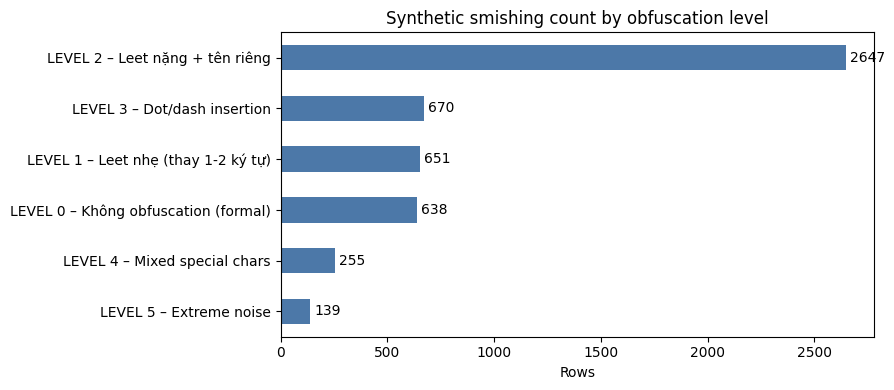

In [3]:
level_counts = df['level'].value_counts().rename_axis('level').to_frame('count')
level_counts['percent'] = 100 * level_counts['count'] / len(df)
display(level_counts)

ax = level_counts.sort_values('count').plot.barh(y='count', legend=False, figsize=(9, 4), color='#4C78A8')
ax.set_title('Synthetic smishing count by obfuscation level')
ax.set_xlabel('Rows')
ax.set_ylabel('')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.tight_layout()

## Category Contribution

A global imbalance can come from one category or from a broad generation policy. This cross-tab shows where `LEVEL 2` is concentrated.

level,LEVEL 0 – Không obfuscation (formal),LEVEL 1 – Leet nhẹ (thay 1-2 ký tự),LEVEL 2 – Leet nặng + tên riêng,LEVEL 3 – Dot/dash insertion,LEVEL 4 – Mixed special chars,LEVEL 5 – Extreme noise
category,,,,,,
BHXH / Trợ cấp,0,209,467,3,0,2
Crypto / Đầu tư giả,3,13,540,135,29,0
Cờ bạc / Betting,0,12,537,132,40,0
Dịch vụ công giả,93,92,364,0,0,0
Giả mạo ngân hàng,38,98,318,0,0,0
Nội dung nhạy cảm,0,0,1,398,186,137
Tuyển dụng giả,253,142,279,2,0,0
Đòi nợ / Đe dọa,251,85,141,0,0,0


level,LEVEL 0 – Không obfuscation (formal),LEVEL 1 – Leet nhẹ (thay 1-2 ký tự),LEVEL 2 – Leet nặng + tên riêng,LEVEL 3 – Dot/dash insertion,LEVEL 4 – Mixed special chars,LEVEL 5 – Extreme noise
category,,,,,,
BHXH / Trợ cấp,0.0,30.7,68.6,0.4,0.0,0.3
Crypto / Đầu tư giả,0.4,1.8,75.0,18.8,4.0,0.0
Cờ bạc / Betting,0.0,1.7,74.5,18.3,5.5,0.0
Dịch vụ công giả,16.9,16.8,66.3,0.0,0.0,0.0
Giả mạo ngân hàng,8.4,21.6,70.0,0.0,0.0,0.0
Nội dung nhạy cảm,0.0,0.0,0.1,55.1,25.8,19.0
Tuyển dụng giả,37.4,21.0,41.3,0.3,0.0,0.0
Đòi nợ / Đe dọa,52.6,17.8,29.6,0.0,0.0,0.0


,level2_count,category_total,level2_percent_within_category,share_of_all_level2
category,,,,
Crypto / Đầu tư giả,540,720,75.0,20.4
Cờ bạc / Betting,537,721,74.5,20.3
BHXH / Trợ cấp,467,681,68.6,17.6
Dịch vụ công giả,364,549,66.3,13.8
Giả mạo ngân hàng,318,454,70.0,12.0
Tuyển dụng giả,279,676,41.3,10.5
Đòi nợ / Đe dọa,141,477,29.6,5.3
Nội dung nhạy cảm,1,722,0.1,0.0


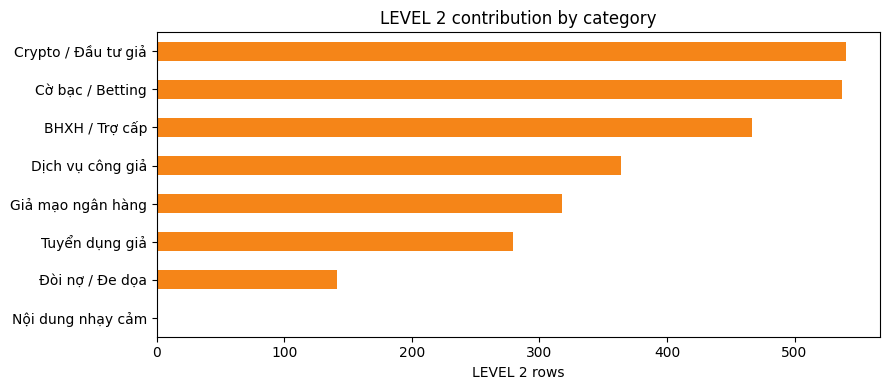

In [4]:
cat_level = pd.crosstab(df['category'], df['level'])
cat_level_pct = pd.crosstab(df['category'], df['level'], normalize='index') * 100

display(cat_level)
display(cat_level_pct.round(1))

level2_by_cat = cat_level.get(LEVEL2, pd.Series(dtype=int)).sort_values(ascending=False).to_frame('level2_count')
level2_by_cat['category_total'] = df['category'].value_counts()
level2_by_cat['level2_percent_within_category'] = 100 * level2_by_cat['level2_count'] / level2_by_cat['category_total']
level2_by_cat['share_of_all_level2'] = 100 * level2_by_cat['level2_count'] / level2_by_cat['level2_count'].sum()
display(level2_by_cat.round(1))

ax = level2_by_cat.sort_values('level2_count').plot.barh(y='level2_count', legend=False, figsize=(9, 4), color='#F58518')
ax.set_title('LEVEL 2 contribution by category')
ax.set_xlabel('LEVEL 2 rows')
ax.set_ylabel('')
plt.tight_layout()

## Observed vs Expected Level Counts

This residual table compares actual category-level counts against an independence baseline. Large positive residuals mean a category has more rows at that level than expected from the category size and level size alone.

Use this to identify where `LEVEL 2` is structurally over-assigned.

In [5]:
observed = pd.crosstab(df['category'], df['level'])
expected = np.outer(observed.sum(axis=1), observed.sum(axis=0)) / observed.values.sum()
expected = pd.DataFrame(expected, index=observed.index, columns=observed.columns)
std_resid = (observed - expected) / np.sqrt(expected)

display(std_resid.round(2).sort_values(LEVEL2, ascending=False))

resid_long = std_resid.stack().rename('std_residual').reset_index()
display(resid_long.sort_values('std_residual', ascending=False).head(15))
display(resid_long.sort_values('std_residual', ascending=True).head(15))

level,LEVEL 0 – Không obfuscation (formal),LEVEL 1 – Leet nhẹ (thay 1-2 ký tự),LEVEL 2 – Leet nặng + tên riêng,LEVEL 3 – Dot/dash insertion,LEVEL 4 – Mixed special chars,LEVEL 5 – Extreme noise
category,,,,,,
Crypto / Đầu tư giả,-9.27,-8.34,8.14,3.92,-1.27,-4.47
Cờ bạc / Betting,-9.59,-8.45,7.95,3.60,0.53,-4.48
BHXH / Trợ cấp,-9.32,12.78,5.61,-9.24,-5.89,-3.89
Giả mạo ngân hàng,-2.62,5.06,5.01,-7.80,-4.81,-3.55
Dịch vụ công giả,2.74,2.43,4.30,-8.58,-5.29,-3.91
Tuyển dụng giả,17.95,5.75,-4.17,-9.31,-5.87,-4.34
Đòi nợ / Đe dọa,24.37,2.91,-7.02,-7.99,-4.93,-3.64
Nội dung nhạy cảm,-9.60,-9.70,-19.50,30.63,24.58,26.10


,category,level,std_residual
33,Nội dung nhạy cảm,LEVEL 3 – Dot/dash insertion,30.627316
35,Nội dung nhạy cảm,LEVEL 5 – Extreme noise,26.099309
34,Nội dung nhạy cảm,LEVEL 4 – Mixed special chars,24.583918
42,Đòi nợ / Đe dọa,LEVEL 0 – Không obfuscation (formal),24.371210
36,Tuyển dụng giả,LEVEL 0 – Không obfuscation (formal),17.953427
1,BHXH / Trợ cấp,LEVEL 1 – Leet nhẹ (thay 1-2 ký tự),12.779345
8,Crypto / Đầu tư giả,LEVEL 2 – Leet nặng + tên riêng,8.135416
14,Cờ bạc / Betting,LEVEL 2 – Leet nặng + tên riêng,7.949121
37,Tuyển dụng giả,LEVEL 1 – Leet nhẹ (thay 1-2 ký tự),5.754302
2,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,5.607855


,category,level,std_residual
32,Nội dung nhạy cảm,LEVEL 2 – Leet nặng + tên riêng,-19.499472
31,Nội dung nhạy cảm,LEVEL 1 – Leet nhẹ (thay 1-2 ký tự),-9.695587
30,Nội dung nhạy cảm,LEVEL 0 – Không obfuscation (formal),-9.598292
12,Cờ bạc / Betting,LEVEL 0 – Không obfuscation (formal),-9.591642
0,BHXH / Trợ cấp,LEVEL 0 – Không obfuscation (formal),-9.321781
39,Tuyển dụng giả,LEVEL 3 – Dot/dash insertion,-9.307425
6,Crypto / Đầu tư giả,LEVEL 0 – Không obfuscation (formal),-9.271999
3,BHXH / Trợ cấp,LEVEL 3 – Dot/dash insertion,-9.238648
21,Dịch vụ công giả,LEVEL 3 – Dot/dash insertion,-8.577062
13,Cờ bạc / Betting,LEVEL 1 – Leet nhẹ (thay 1-2 ký tự),-8.450335


## Text Feature Engineering

The metrics below are proxies, not ground truth. They are useful for finding rows whose assigned level does not match their surface form.

- `digit_ratio`: how much the text depends on numeric substitutions.
- `symbol_ratio`: punctuation and special-character density.
- `leet_char_count`: count of common leet substitution characters.
- `dot_dash_inside_token_count`: likely dot/dash insertion inside words.
- `random_suffix_flag`: generated-looking trailing code, common in synthetic examples.
- `vietnamese_diacritic_count`: whether heavy leet removed Vietnamese orthographic signal.
- `name_hint_count`: weak proxy for names or direct personal addressing.

In [6]:
leet_chars = set('40135789@$!|+zZ')
vn_diacritic_re = re.compile(r'[àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđÀÁẠẢÃÂẦẤẬẨẪĂẰẮẶẲẴÈÉẸẺẼÊỀẾỆỂỄÌÍỊỈĨÒÓỌỎÕÔỒỐỘỔỖƠỜỚỢỞỠÙÚỤỦŨƯỪỨỰỬỮỲÝỴỶỸĐ]')
dot_dash_inside_token_re = re.compile(r'(?iu)\b\w+[.-]\w+(?:[.-]\w+)*\b')
url_re = re.compile(r'(?iu)\b(?:https?://|www\.|[a-z0-9-]+\.(?:com|vn|net|org|info|icu|top|xyz|site|me)\b)')
phone_like_re = re.compile(r'(?<!\d)(?:\+?84|0)\d{8,10}(?!\d)|(?<!\d)\d{3,5}(?!\d)')
random_suffix_re = re.compile(r'(?u)(?:\s|^)[A-Za-z]{1,3}\d[A-Za-z0-9]{1,4}\s*$')
name_hint_re = re.compile(r'(?iu)\b(?:anh|chị|chi|ông|ong|bà|ba|cô|co|chú|chu|quý khách|quy khach|khách hàng|khach hang|bạn|ban)\b')

def char_stats(text: str) -> pd.Series:
    chars = [c for c in text if not c.isspace()]
    n = max(len(chars), 1)
    letters = [c for c in chars if c.isalpha()]
    return pd.Series({
        'char_count': len(text),
        'token_count': len(re.findall(r'\S+', text)),
        'digit_count': sum(c.isdigit() for c in chars),
        'digit_ratio': sum(c.isdigit() for c in chars) / n,
        'symbol_count': sum((not c.isalnum()) for c in chars),
        'symbol_ratio': sum((not c.isalnum()) for c in chars) / n,
        'upper_ratio': (sum(c.isupper() for c in letters) / max(len(letters), 1)),
        'leet_char_count': sum(c in leet_chars for c in chars),
        'leet_char_ratio': sum(c in leet_chars for c in chars) / n,
        'vietnamese_diacritic_count': len(vn_diacritic_re.findall(text)),
        'dot_dash_inside_token_count': len(dot_dash_inside_token_re.findall(text)),
        'url_like_count': len(url_re.findall(text)),
        'phone_like_count': len(phone_like_re.findall(text)),
        'random_suffix_flag': int(bool(random_suffix_re.search(text))),
        'name_hint_count': len(name_hint_re.findall(text)),
    })

features = df['content'].apply(char_stats)
eda = pd.concat([df, features], axis=1)
display(eda.head())

,content,label,has_url,has_phone_number,sender_type,category,level,char_count,token_count,digit_count,...,symbol_ratio,upper_ratio,leet_char_count,leet_char_ratio,vietnamese_diacritic_count,dot_dash_inside_token_count,url_like_count,phone_like_count,random_suffix_flag,name_hint_count
0,[TB] BHXH: B4n da zu d!eu k!en nh4n t1en h0 tr0 tu wy BHTN nq-116. B4m v4o www.zkxpw.icu. QU4 H4N KH0NG ZU0C CH4P NH4N! xR7p,1,1,0,personal_number,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,124.0,25.0,17.0,...,0.110000,0.416667,22.0,0.220000,0.0,2.0,2.0,1.0,1.0,0.0
1,Ong (Ba) da zu d!eu k1en NH4N T1EN ho tro tu wy BHTN. B4m v4o www.qpwnm.icu de l4y. QU4 H4N KH0NG ZU0C CH4P NH4N. aS9k,1,1,0,personal_number,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,118.0,25.0,13.0,...,0.085106,0.424658,16.0,0.170213,0.0,1.0,2.0,0.0,1.0,2.0
2,Quy BH-TN: B4n da zu d!eu k1en nh4n t1en h0 tr0 theo NQ-116. B4m v4o www.lkytr.icu. QU4 H4N KH0NG ZU0C CH4P NH4N. mZ4w,1,1,0,personal_number,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,118.0,23.0,18.0,...,0.093750,0.391304,21.0,0.218750,0.0,3.0,2.0,1.0,1.0,0.0
3,[BHXH] Quyet zinh BHXH: Ong(Ba) da zu d!eu k1en nh4n t1en. B4m v4o www.vnbgt.icu. QU4 H4N KH0NG ZU0C CH4P NH4N. kP1o,1,1,0,personal_number,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,116.0,21.0,12.0,...,0.114583,0.410959,16.0,0.166667,0.0,1.0,2.0,0.0,1.0,2.0
4,BHXH_VN: B4n da zu d!eu k1en nh4n t1en h0 tr0 BHTN. B4m v4o www.mkhgf.icu. QU4 H4N KH0NG ZU0C CH4P NH4N. rT8y,1,1,0,personal_number,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,109.0,21.0,15.0,...,0.089888,0.454545,18.0,0.202247,0.0,1.0,2.0,0.0,1.0,0.0


## Feature Summary by Level

This view checks whether `LEVEL 2` is meaningfully distinct. If it looks similar to `LEVEL 1`, `LEVEL 3`, or `LEVEL 4`, the taxonomy may be too ambiguous or the generation process may have blended transformations.

char_count        token_count         \
                                           mean median        mean median   
level                                                                       
LEVEL 0 – Không obfuscation (formal)    172.382  168.0      32.303   29.0   
LEVEL 1 – Leet nhẹ (thay 1-2 ký tự)     124.773  121.0      22.624   22.0   
LEVEL 2 – Leet nặng + tên riêng         109.717  106.0      18.618   18.0   
LEVEL 3 – Dot/dash insertion             94.313   95.0       7.921    6.0   
LEVEL 4 – Mixed special chars            87.208   86.0       6.118    6.0   
LEVEL 5 – Extreme noise                  81.626   78.0       5.705    5.0   

                                     digit_ratio        symbol_ratio         \
                                            mean median         mean median   
level                                                                         
LEVEL 0 – Không obfuscation (formal)       0.154  0.172        0.067  0.069   
LEVEL 1 – Leet nhẹ (thay 1-2 ký tự)        0.243  0.224        0.092  0.090   
LEVEL 2 – Leet nặng + tên riêng            0.254  0.247        0.110  0.093   
LEVEL 3 – Dot/dash insertion               0.097  0.045        0.307  0.316   
LEVEL 4 – Mixed special chars              0.097  0.074        0.303  0.289   
LEVEL 5 – Extreme noise                    0.043  0.044        0.366  0.371   

                                     upper_ratio         ...  \
                                            mean median  ...   
level                                                    ...   
LEVEL 0 – Không obfuscation (formal)       0.141  0.118  ...   
LEVEL 1 – Leet nhẹ (thay 1-2 ký tự)        0.282  0.216  ...   
LEVEL 2 – Leet nặng + tên riêng            0.238  0.176  ...   
LEVEL 3 – Dot/dash insertion               0.184  0.143  ...   
LEVEL 4 – Mixed special chars              0.201  0.175  ...   
LEVEL 5 – Extreme noise                    0.241  0.243  ...   

                                     dot_dash_inside_token_count         \
                                                            mean median   
level                                                                     
LEVEL 0 – Không obfuscation (formal)                       1.172    1.0   
LEVEL 1 – Leet nhẹ (thay 1-2 ký tự)                        1.680    1.0   
LEVEL 2 – Leet nặng + tên riêng                            1.854    1.0   
LEVEL 3 – Dot/dash insertion                               4.682    3.0   
LEVEL 4 – Mixed special chars                              2.788    2.0   
LEVEL 5 – Extreme noise                                    2.935    2.0   

                                     url_like_count        phone_like_count  \
                                               mean median             mean   
level                                                                         
LEVEL 0 – Không obfuscation (formal)          0.531    0.0            2.387   
LEVEL 1 – Leet nhẹ (thay 1-2 ký tự)           0.985    1.0            1.255   
LEVEL 2 – Leet nặng + tên riêng               0.716    1.0            1.085   
LEVEL 3 – Dot/dash insertion                  0.615    1.0            0.370   
LEVEL 4 – Mixed special chars                 0.686    1.0            0.259   
LEVEL 5 – Extreme noise                       0.741    1.0            0.007   

                                            random_suffix_flag         \
                                     median               mean median   
level                                                                   
LEVEL 0 – Không obfuscation (formal)    3.0              0.000    0.0   
LEVEL 1 – Leet nhẹ (thay 1-2 ký tự)     1.0              0.335    0.0   
LEVEL 2 – Leet nặng + tên riêng         1.0              0.243    0.0   
LEVEL 3 – Dot/dash insertion            0.0              0.467    0.0   
LEVEL 4 – Mixed special chars           0.0              0.573    1.0   
LEVEL 5 – Extreme noise                 0.0              0.727    1.0   

        

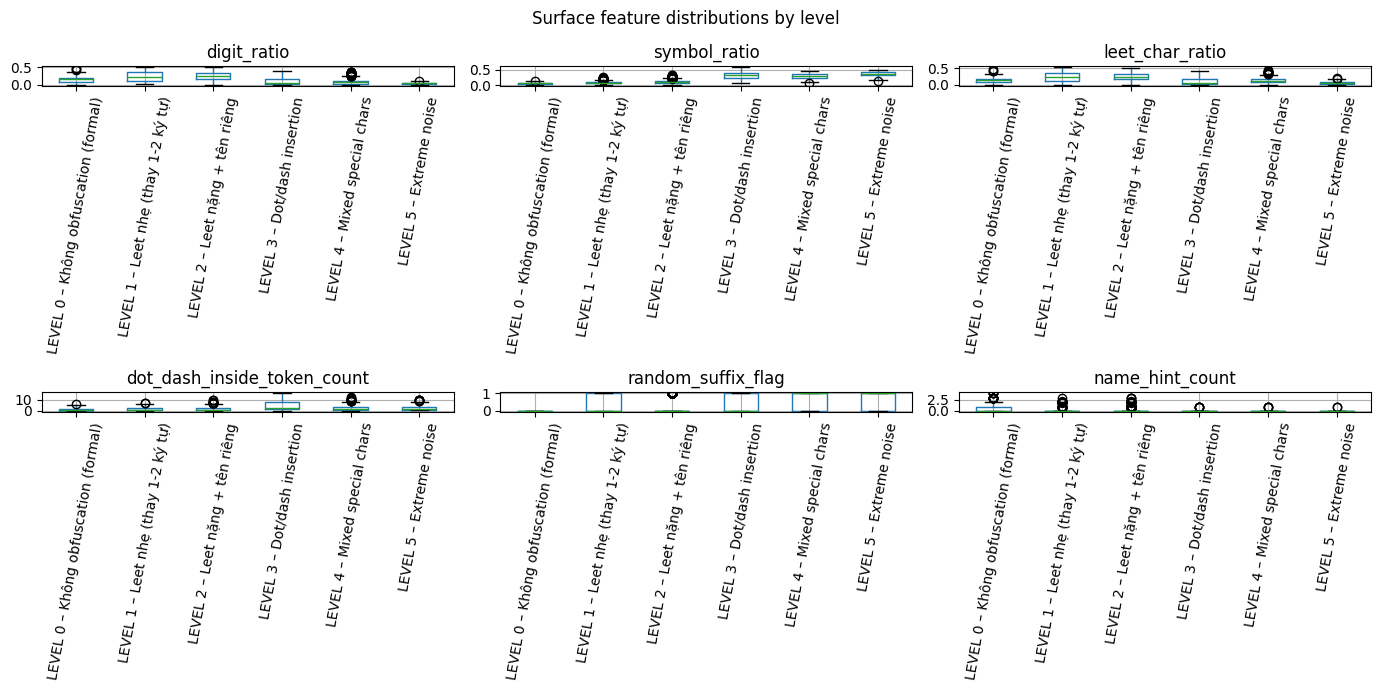

In [7]:
feature_cols = [
    'char_count', 'token_count', 'digit_ratio', 'symbol_ratio', 'upper_ratio',
    'leet_char_ratio', 'vietnamese_diacritic_count', 'dot_dash_inside_token_count',
    'url_like_count', 'phone_like_count', 'random_suffix_flag', 'name_hint_count'
]

summary_by_level = eda.groupby('level')[feature_cols].agg(['mean', 'median']).round(3)
display(summary_by_level)

plot_cols = ['digit_ratio', 'symbol_ratio', 'leet_char_ratio', 'dot_dash_inside_token_count', 'random_suffix_flag', 'name_hint_count']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), plot_cols):
    eda.boxplot(column=col, by='level', ax=ax, rot=80)
    ax.set_title(col)
    ax.set_xlabel('')
fig.suptitle('Surface feature distributions by level')
plt.tight_layout()

## LEVEL 2 vs Non-LEVEL 2

This binary comparison is useful for deciding whether the overrepresented class has a coherent signature. Weak separation suggests relabeling or taxonomy revision; strong separation suggests the issue is mainly distributional.

In [8]:
eda['is_level2'] = eda['level'].eq(LEVEL2)

binary_summary = eda.groupby('is_level2')[feature_cols].agg(['mean', 'median', 'std']).round(3)
display(binary_summary)

effect_rows = []
for col in feature_cols:
    a = eda.loc[eda['is_level2'], col].astype(float)
    b = eda.loc[~eda['is_level2'], col].astype(float)
    pooled = math.sqrt(((a.var(ddof=1) + b.var(ddof=1)) / 2)) if len(a) > 1 and len(b) > 1 else np.nan
    effect_rows.append({
        'feature': col,
        'level2_mean': a.mean(),
        'non_level2_mean': b.mean(),
        'mean_diff': a.mean() - b.mean(),
        'cohens_d_approx': (a.mean() - b.mean()) / pooled if pooled and not np.isnan(pooled) else np.nan,
    })

effect_df = pd.DataFrame(effect_rows).sort_values('cohens_d_approx', key=lambda s: s.abs(), ascending=False)
display(effect_df.round(3))

char_count                token_count                digit_ratio  \
                mean median     std        mean median     std        mean   
is_level2                                                                    
False        122.389  110.0  46.643      18.273   17.0  13.117       0.150   
True         109.717  106.0  28.586      18.618   18.0   7.451       0.254   

                        symbol_ratio  ... url_like_count phone_like_count  \
          median    std         mean  ...            std             mean   
is_level2                             ...                                   
False      0.138  0.123        0.186  ...          0.699            1.128   
True       0.247  0.109        0.110  ...          0.752            1.085   

                        random_suffix_flag               name_hint_count  \
          median    std               mean median    std            mean   
is_level2                                                                  
False        0.0  1.432              0.331    0.0  0.471           0.297   
True         1.0  1.308              0.243    0.0  0.429           0.125   

                         
          median    std  
is_level2                
False        0.0  0.653  
True         0.0  0.422  

[2 rows x 36 columns]

,feature,level2_mean,non_level2_mean,mean_diff,cohens_d_approx
5,leet_char_ratio,0.255,0.152,0.103,0.964
2,digit_ratio,0.254,0.150,0.105,0.900
3,symbol_ratio,0.110,0.186,-0.076,-0.744
6,vietnamese_diacritic_count,0.188,5.200,-5.012,-0.694
0,char_count,109.717,122.389,-12.672,-0.328
7,dot_dash_inside_token_count,1.854,2.592,-0.737,-0.326
11,name_hint_count,0.125,0.297,-0.172,-0.314
4,upper_ratio,0.238,0.205,0.033,0.212
10,random_suffix_flag,0.243,0.331,-0.088,-0.195
1,token_count,18.618,18.273,0.345,0.032


## Category-Specific LEVEL 2 Behavior

`LEVEL 2` may not mean the same thing in every category. For example, gambling and crypto rows may use more URL/domain patterns, while benefit-scam rows may use more official-language templates.

,char_count,token_count,digit_ratio,symbol_ratio,upper_ratio,leet_char_ratio,vietnamese_diacritic_count,dot_dash_inside_token_count,url_like_count,phone_like_count,random_suffix_flag,name_hint_count,rows
category,,,,,,,,,,,,,
Crypto / Đầu tư giả,107.878,19.089,0.281,0.090,0.164,0.281,0.019,1.372,0.363,0.826,0.000,0.102,540
Cờ bạc / Betting,85.920,13.300,0.257,0.150,0.226,0.244,0.007,2.318,0.309,1.380,0.218,0.035,537
BHXH / Trợ cấp,119.782,17.251,0.114,0.156,0.510,0.145,0.028,3.028,1.595,0.381,0.991,0.360,467
Dịch vụ công giả,97.750,18.918,0.248,0.077,0.144,0.247,1.223,0.940,0.681,0.560,0.093,0.110,364
Giả mạo ngân hàng,98.425,18.028,0.217,0.078,0.153,0.225,0.057,1.079,0.931,0.142,0.088,0.063,318
Tuyển dụng giả,127.620,20.194,0.430,0.094,0.134,0.417,0.022,2.760,0.867,3.065,0.000,0.000,279
Đòi nợ / Đe dọa,195.199,39.071,0.355,0.060,0.308,0.334,0.007,0.369,0.000,2.865,0.000,0.206,141
Nội dung nhạy cảm,81.000,15.000,0.045,0.104,0.088,0.045,0.000,1.000,1.000,0.000,1.000,0.000,1


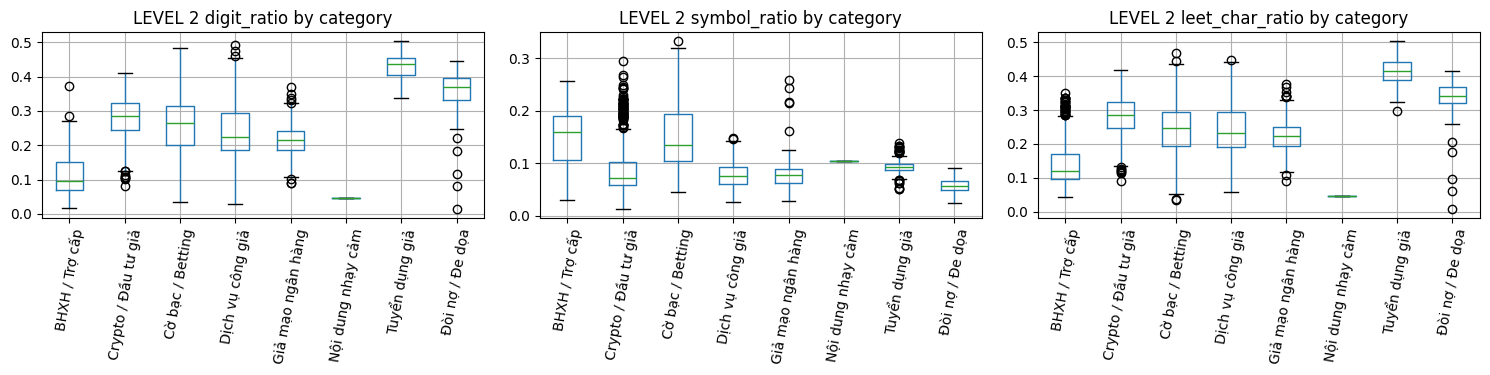

In [9]:
level2 = eda[eda['is_level2']].copy()

level2_cat_features = level2.groupby('category')[feature_cols].mean().round(3)
level2_cat_features['rows'] = level2['category'].value_counts()
display(level2_cat_features.sort_values('rows', ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['digit_ratio', 'symbol_ratio', 'leet_char_ratio']):
    level2.boxplot(column=col, by='category', ax=ax, rot=80)
    ax.set_title(f'LEVEL 2 {col} by category')
    ax.set_xlabel('')
fig.suptitle('')
plt.tight_layout()

## Template Reuse and Generation Artifacts

Heavy overrepresentation is more concerning if the level is also template-heavy. The skeleton below removes common volatile parts such as URLs, phone-like numbers, and trailing random codes. High skeleton duplication means the dataset may teach models a small set of synthetic templates rather than robust smishing cues.

In [10]:
def strip_accents(text: str) -> str:
    return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')

def skeletonize(text: str) -> str:
    x = strip_accents(text.lower())
    x = url_re.sub('<URL>', x)
    x = phone_like_re.sub('<NUM>', x)
    x = random_suffix_re.sub(' <SUFFIX>', x)
    x = re.sub(r'\d+', '<NUM>', x)
    x = re.sub(r'[^a-z<>]+', ' ', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x

eda['skeleton'] = eda['content'].map(skeletonize)
level2 = eda[eda['is_level2']].copy()

skeleton_stats = eda.groupby(['level', 'skeleton']).size().rename('count').reset_index()
top_skeletons = skeleton_stats.sort_values('count', ascending=False).head(30)
display(top_skeletons)

reuse_by_level = skeleton_stats.groupby('level')['count'].agg(
    rows='sum',
    unique_skeletons='count',
    max_skeleton_reuse='max',
    skeletons_reused_3plus=lambda s: int((s >= 3).sum()),
    rows_in_reused_3plus=lambda s: int(s[s >= 3].sum()),
)
reuse_by_level['rows_per_skeleton'] = reuse_by_level['rows'] / reuse_by_level['unique_skeletons']
reuse_by_level['pct_rows_in_reused_3plus'] = 100 * reuse_by_level['rows_in_reused_3plus'] / reuse_by_level['rows']
display(reuse_by_level.round(2).sort_values('pct_rows_in_reused_3plus', ascending=False))

,level,skeleton,count
739,LEVEL 1 – Leet nhẹ (thay 1-2 ký tự),bhxh vn < >ng b< > da du d eu k< >en nh< >n t< >en h< > tr< > tu quy bhtn b< >m v< > < >< > qua han se kh< >ng du< >c chap nhan < >,5
952,LEVEL 1 – Leet nhẹ (thay 1-2 ký tự),hoan thue tncn b< >n d< > du d eu k< >en nh< >n t< >en h< >n thue b< >m v< > < >< > qua han se kh< >ng du< >c chap nhan < >,5
776,LEVEL 1 – Leet nhẹ (thay 1-2 ký tự),bo ld tb xh < >ng b< > da du d eu k< >en nh< >n t< >en h< > tr< > theo nq < > b< >m v< > < >< > qua han se kh< >ng du< >c chap nhan < >,4
1033,LEVEL 1 – Leet nhẹ (thay 1-2 ký tự),quy bhtn ong ba da du d eu k en nhan t< >en h< > tro bam vao mo < > qua han se kh< >ng duoc chap nhan < >,4
1029,LEVEL 1 – Leet nhẹ (thay 1-2 ký tự),quy bhtn b< >n da du d eu k en nh< >n t< >en tu bo ld tb xh bam vao < >< > qua han se kh< >ng duoc chap nhan < >,4
2658,LEVEL 2 – Leet nặng + tên riêng,ho tro covid < > b< >n da du d eu k en nh< >n t< >en h< > tro tu quy bh tn bam v< > < >< > qua han se kh< >ng duoc chap nhan < >,4
969,LEVEL 1 – Leet nhẹ (thay 1-2 ký tự),hoan thue tncn ong ba da du d eu k en nhan t< >en tu quy bhtn bam vao < >< > qua han se kh< >ng duoc chap nhan < >,3
20,LEVEL 0 – Không obfuscation (formal),amazon can tuyen nhan vien xu ly on at hang tm t tai nha thu nhap < >k < >k ngay yeu cau < > < > tuoi thao tac on gian lien he zalo < > < > zalo < >,3
1805,LEVEL 2 – Leet nặng + tên riêng,bhxh vn < >ng b< > z< > zu z < >u k < >n nh< >n t< >n h< > tr< > tu quy bhtn b< >m v< > < >< > qua han se kh< >ng zu< >c ch< >p nh< >n < >,3
1445,LEVEL 2 – Leet nặng + tên riêng,< >ng b< > da du d eu k< >en nh< >n t< >en h< > tro tu quy bhtn bam v< >o < >< > qua han se kh< >ng duoc chap nhan < >,3


,rows,unique_skeletons,max_skeleton_reuse,skeletons_reused_3plus,rows_in_reused_3plus,rows_per_skeleton,pct_rows_in_reused_3plus
level,,,,,,,
LEVEL 1 – Leet nhẹ (thay 1-2 ký tự),651,619,5,6,25,1.05,3.84
LEVEL 2 – Leet nặng + tên riêng,2647,2602,4,8,25,1.02,0.94
LEVEL 0 – Không obfuscation (formal),638,633,3,1,3,1.01,0.47
LEVEL 3 – Dot/dash insertion,670,670,1,0,0,1.00,0.00
LEVEL 4 – Mixed special chars,255,255,1,0,0,1.00,0.00
LEVEL 5 – Extreme noise,139,139,1,0,0,1.00,0.00


## Suspicious LEVEL 2 Rows

These rows are useful for manual audit. They are still labeled `LEVEL 2`, but their surface metrics suggest they may be closer to another level or may reflect synthetic artifacts.

In [11]:
level2_thresholds = {
    'low_leet': level2['leet_char_ratio'].quantile(0.10),
    'high_symbol': level2['symbol_ratio'].quantile(0.90),
    'high_dotdash': level2['dot_dash_inside_token_count'].quantile(0.90),
}
level2_thresholds

suspicious_level2 = level2[
    (level2['leet_char_ratio'] <= level2_thresholds['low_leet']) |
    (level2['dot_dash_inside_token_count'] >= max(1, level2_thresholds['high_dotdash'])) |
    (level2['random_suffix_flag'].eq(1))
].copy()

review_cols = [
    'content', 'category', 'level', 'has_url', 'has_phone_number', 'sender_type',
    'digit_ratio', 'symbol_ratio', 'leet_char_ratio', 'dot_dash_inside_token_count',
    'random_suffix_flag', 'name_hint_count', 'skeleton'
]

display(suspicious_level2[review_cols].sort_values(['category', 'leet_char_ratio']).head(80))

,content,category,level,has_url,has_phone_number,sender_type,digit_ratio,symbol_ratio,leet_char_ratio,dot_dash_inside_token_count,random_suffix_flag,name_hint_count,skeleton
1172,Quyet_dinh_BHXH: Ong(Ba) da_du-d!eu_k!en nhan_t1en tu quy-BHTN. Bam-vao www.olpki.icu. QUA-HAN*SE_KH0NG*DUOC*CHAP-NHAN! fD2s,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,1,0,personal_number,0.026087,0.208696,0.043478,6.0,1.0,2.0,quyet dinh bhxh ong ba da du d eu k en nhan t< >en tu quy bhtn bam vao < >< > qua han se kh< >ng duoc chap nhan < >
252,[T.B] BHXH: Ong (Ba) da du d!eu k!en nhan t1en ho tro tu BHTN. Bam vao www.poiuyt.icu. QUA HAN SE KH0NG DUOC CHAP NHAN! bN6m,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,1,0,personal_number,0.030000,0.130000,0.050000,2.0,1.0,2.0,t b bhxh ong ba da du d eu k en nhan t< >en ho tro tu bhtn bam vao < >< > qua han se kh< >ng duoc chap nhan < >
1166,BHXH-Viet-Nam: Ong~Ba da_du d!eu*k!en nhan-tien Quyet-dinh-BHXH. Bam-vao www.qazws.icu. QUA-HAN_SE_KH0NG_DUOC_CHAP_NHAN! yU5n,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,1,0,personal_number,0.017241,0.198276,0.051724,6.0,1.0,2.0,bhxh viet nam ong ba da du d eu k en nhan tien quyet dinh bhxh bam vao < >< > qua han se kh< >ng duoc chap nhan < >
1711,Quyet-dinh_BHXH: Ong(Ba)_da^du_D!EU-K!EN*nhan-t1en_tu-BHTN. Bam-vao: www.olpzx.icu. QUA-HAN_SE_KH0NG_DUOC_CHAP_NHAN! aS2d,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,1,0,personal_number,0.025862,0.241379,0.051724,6.0,1.0,2.0,quyet dinh bhxh ong ba da du d eu k en nhan t< >en tu bhtn bam vao < >< > qua han se kh< >ng duoc chap nhan < >
1721,Bo-LD-TB-XH: Ong/Ba_da~du*D!EU-K!EN_nhan-t1en_tu_BHXH_VN. Bam-vao: mo.plmko.com. QUA-HAN_SE_KH0NG_DUOC_CHAP_NHAN! mJ5n,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,1,0,personal_number,0.026549,0.256637,0.053097,6.0,1.0,1.0,bo ld tb xh ong ba da du d eu k en nhan t< >en tu bhxh vn bam vao mo < > qua han se kh< >ng duoc chap nhan < >
79,Quyet_dinh_BHXH: Ong^Ba_da_du_d!eu_k!en_nhan_t1en_BHTN. Bam_vao_www.olpkh.icu. QUA_HAN_SE_KH0NG_DUOC_CHAP_NHAN! fG5h,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,1,0,personal_number,0.026786,0.232143,0.053571,1.0,1.0,1.0,quyet dinh bhxh ong ba da du d eu k en nhan t< >en bhtn bam vao www < > qua han se kh< >ng duoc chap nhan < >
1176,Hoan-thue-TNCN: Ong(Ba) da_du-d!eu_k!en nhan_t1en hoan-thue. Bam-vao mo.vfrtg.com. QUA-HAN*SE*KH0NG_DUOC-CHAP-NHAN! vB5n,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,1,0,personal_number,0.026786,0.214286,0.053571,7.0,1.0,2.0,hoan thue tncn ong ba da du d eu k en nhan t< >en hoan thue bam vao mo < > qua han se kh< >ng duoc chap nhan < >
52,B0-LD-TB-XH_TB: Ong^Ba_da_du_d!eu_k!en-nhan_t1en*BHTN. Bam_vao_www.mnbvc.icu. QUA_HAN_SE_KH0NG_DUOC_CHAP_NHAN! tY2u,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,1,0,personal_number,0.036036,0.252252,0.054054,3.0,1.0,1.0,b< > ld tb xh tb ong ba da du d eu k en nhan t< >en bhtn bam vao www < > qua han se kh< >ng duoc chap nhan < >
4160,B0_LĐ-TB-XH: Ong-Ba_da-du_d!eu-k!en-NHAN_T1EN-ho_tro. Bam_vao_www.cdew2.icu. QUA-HAN_SE_KH0NG^DUOC-CHAP_NHAN! aS2d,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,1,0,personal_number,0.045455,0.254545,0.054545,7.0,1.0,1.0,b< > l tb xh ong ba da du d eu k en nhan t< >en ho tro bam vao www < > qua han se kh< >ng duoc chap nhan < >
3023,Quy BHTN: Ong (Ba) da du d!eu k!en nhan tro cap theo NQ-116. Bam vao www.xncvb.icu de nhan. QUA HAN SE KH0NG DUOC CHAP NHAN. mJ7n,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,1,0,personal_number,0.048077,0.105769,0.057692,2.0,1.0,2.0,quy bhtn ong ba da du d eu k en nhan tro cap theo nq < > bam vao < >< > de nhan qua han se kh< >ng duoc chap nhan < >


## Representative Samples for Manual Review

This sample intentionally mixes typical, low-leet, high-symbol, and high-template-reuse examples. Review these rows by hand before deciding whether to relabel or regenerate.

In [12]:
rng = np.random.default_rng(42)

sample_parts = []
for category, g in level2.groupby('category'):
    sample_parts.append(g.sample(min(5, len(g)), random_state=42))
    sample_parts.append(g.nsmallest(min(5, len(g)), 'leet_char_ratio'))
    sample_parts.append(g.nlargest(min(5, len(g)), 'symbol_ratio'))

review_sample = pd.concat(sample_parts, ignore_index=False).drop_duplicates().copy()
review_sample = review_sample[review_cols].sort_values(['category', 'leet_char_ratio', 'symbol_ratio'])
review_sample.to_csv(SAMPLE_OUT, index=False, encoding='utf-8-sig')

print(f'Wrote {len(review_sample)} rows to {SAMPLE_OUT}')
display(review_sample.head(120))

Wrote 102 rows to level2_review_samples.csv


,content,category,level,has_url,has_phone_number,sender_type,digit_ratio,symbol_ratio,leet_char_ratio,dot_dash_inside_token_count,random_suffix_flag,name_hint_count,skeleton
1172,Quyet_dinh_BHXH: Ong(Ba) da_du-d!eu_k!en nhan_t1en tu quy-BHTN. Bam-vao www.olpki.icu. QUA-HAN*SE_KH0NG*DUOC*CHAP-NHAN! fD2s,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,1,0,personal_number,0.026087,0.208696,0.043478,6.0,1.0,2.0,quyet dinh bhxh ong ba da du d eu k en nhan t< >en tu quy bhtn bam vao < >< > qua han se kh< >ng duoc chap nhan < >
252,[T.B] BHXH: Ong (Ba) da du d!eu k!en nhan t1en ho tro tu BHTN. Bam vao www.poiuyt.icu. QUA HAN SE KH0NG DUOC CHAP NHAN! bN6m,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,1,0,personal_number,0.030000,0.130000,0.050000,2.0,1.0,2.0,t b bhxh ong ba da du d eu k en nhan t< >en ho tro tu bhtn bam vao < >< > qua han se kh< >ng duoc chap nhan < >
1166,BHXH-Viet-Nam: Ong~Ba da_du d!eu*k!en nhan-tien Quyet-dinh-BHXH. Bam-vao www.qazws.icu. QUA-HAN_SE_KH0NG_DUOC_CHAP_NHAN! yU5n,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,1,0,personal_number,0.017241,0.198276,0.051724,6.0,1.0,2.0,bhxh viet nam ong ba da du d eu k en nhan tien quyet dinh bhxh bam vao < >< > qua han se kh< >ng duoc chap nhan < >
1711,Quyet-dinh_BHXH: Ong(Ba)_da^du_D!EU-K!EN*nhan-t1en_tu-BHTN. Bam-vao: www.olpzx.icu. QUA-HAN_SE_KH0NG_DUOC_CHAP_NHAN! aS2d,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,1,0,personal_number,0.025862,0.241379,0.051724,6.0,1.0,2.0,quyet dinh bhxh ong ba da du d eu k en nhan t< >en tu bhtn bam vao < >< > qua han se kh< >ng duoc chap nhan < >
1721,Bo-LD-TB-XH: Ong/Ba_da~du*D!EU-K!EN_nhan-t1en_tu_BHXH_VN. Bam-vao: mo.plmko.com. QUA-HAN_SE_KH0NG_DUOC_CHAP_NHAN! mJ5n,BHXH / Trợ cấp,LEVEL 2 – Leet nặng + tên riêng,1,0,personal_number,0.026549,0.256637,0.053097,6.0,1.0,1.0,bo ld tb xh ong ba da du d eu k en nhan t< >en tu bhxh vn bam vao mo < > qua han se kh< >ng duoc chap nhan < >
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1743,"CANH BAO LAN CUOI!!! PC02 th0ng b4o B4 Ngu-y3n Thu H4 CCCD: 046.092.837.415 ph41 th4nh t04n 7,289,000VND ch0 H0m3 Cr3d1t tru0c 17g h0m n4y. B4t h0p t4c s3 b1 C0ng Kh41 H1NH ANH...",Đòi nợ / Đe dọa,LEVEL 2 – Leet nặng + tên riêng,0,1,personal_number,0.365169,0.089888,0.348315,3.0,0.0,1.0,canh bao lan cuoi pc< > th< >ng b< >o b< > ngu y< >n thu h< > cccd < > < > < > < > ph< > th< >nh t< >n < > < > < >vnd ch< > h< >m< > cr< >d< >t tru< >c < >g h< >m n< >y b< >t h...
323,"CANH BAO LAN CUOI!!! B4 Ly Thu H4 (CMND: 272091837) n0 M1r43 Ass3t 35,467,000VND. Th4nh tu4n ng4y tru0c 16H Ng4y 22/07 d3 tr4nh b1 qu4y r01 d4nh b4 ngu01 th4n. LH: 0911223344.",Đòi nợ / Đe dọa,LEVEL 2 – Leet nặng + tên riêng,0,1,personal_number,0.388889,0.090278,0.354167,0.0,0.0,0.0,canh bao lan cuoi b< > ly thu h< > cmnd < > n< > m< >r< > ass< >t < > < > < >vnd th< >nh tu< >n ng< >y tru< >c < >h ng< >y < > < > d< > tr< >nh b< > qu< >y r< > d< >nh b< > ngu...
1745,"TB KHAN: B4 Vu Thuy Vy CCCD: 079.095.847.361 n0 HD S41s0n 16,847,000VND. H4n cu01 tru0c 16H Ng4y 02/06. N3u kh0ng th4nh t04n s3 b1 n13m ph0ng t41 s4n v4 th0ng b4o v3 d14 phu0ng...",Đòi nợ / Đe dọa,LEVEL 2 – Leet nặng + tên riêng,0,1,personal_number,0.408537,0.091463,0.371951,2.0,0.0,0.0,tb khan b< > vu thuy vy cccd < > < > < > < > n< > hd s< >s< >n < > < > < >vnd h< >n cu< > tru< >c < >h ng< >y < > < > n< >u kh< >ng th< >nh t< >n s< > b< > n< >m ph< >ng t< > s...
2026,TB KH4N: PC02 th0ng b40 0ng/B4 d4ng b1 d13u tr4 t04n b0 th0ng t1n d0 b4t h0p t4c. Y3u c4u co m4t t41 c0 qu4n tr0ng v0ng 24H h04c l13n h3 qu4 s0 84933554433 d3 du0c hu0ng khu4n ...,Đòi nợ / Đe dọa,LEVEL 2 – Leet nặng + tên riêng,0,1,personal_number,0.391608,0.027972,0.377622,0.0,0.0,1.0,tb kh< >n pc< > th< >ng b< > < >ng b< > d< >ng b< > d< >u tr< > t< >n b< > th< >ng t< >n d< > b< >t h< >p t< >c y< >u c< >u co m< >t t< > c< > qu< >n tr< >ng v< >ng < >h h< >c ...


## Decision Framework

Use the EDA outputs to decide one of the following actions before final merging:

### Keep `LEVEL 2` as-is only if

- `LEVEL 2` has a distinct feature profile from neighboring levels,
- overrepresentation is intentional and thesis-justified,
- template reuse is not excessive,
- qualitative review confirms that the leet style resembles real Vietnamese smishing rather than synthetic noise.

### Relabel part of `LEVEL 2` if

- low-leet rows look like `LEVEL 0` or `LEVEL 1`,
- dot/dash-heavy rows look like `LEVEL 3`,
- symbol-heavy rows look like `LEVEL 4`,
- suffix-code artifacts are not part of the intended taxonomy.

### Regenerate or downsample if

- `LEVEL 2` is mostly caused by prompt batching,
- a few categories dominate because generation prompts defaulted to heavy leet,
- repeated skeletons are high enough to reduce dataset diversity,
- the final training setup needs balanced obfuscation exposure.

### Revise taxonomy if

- `Leet nặng` and `tên riêng` are not consistently co-occurring,
- Vietnamese diacritic loss, numeric substitution, name insertion, and random suffixes behave like separate transformations,
- the current levels do not form a monotonic difficulty scale.

## Notes for Thesis Write-Up

The key distinction to document is whether level imbalance is a data-design choice or a generation artifact. If retained, justify it with observed scam-style evidence or a rationale tied to robustness testing. If corrected, document the correction rule, the number of affected rows, and why the corrected distribution better supports evaluation validity.